<a href="https://colab.research.google.com/github/BryanHinostroza/lab10-bh/blob/develop/GLAB10_MDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 10: ANÁLISIS DE CONGLOMERADOS**

Integrantes:
- GUTIERREZ GARCIA, Angela Belen
- HINOSTROZA MARTINEZ, Bryan Jesus

### Con base de la información de la base de datos ‘vehículos’ la cual contiene información sobre diferentes modelos con las características más importantes que los definen, haga lo siguiente:

### **EJERCICIO A:**

Realice el preprocesamiento de la información que incluya el análisis de datos faltantes,tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las
variables numéricas y dumización para las variables categóricas. Además, elimine las variables fabricante, modelo, transmision, traccion, clase, combustible y consumo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
ruta = "/content/drive/MyDrive/vehículos.csv"
df = pd.read_csv(ruta)
df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


In [ ]:
# Revisamos valores nulos
print(df.isnull().sum())

fabricante                0
modelo                    0
year                      0
desplazamiento            2
cilindros                 3
transmision               2
traccion                789
clase                     0
combustible               0
consumo                   0
co2                       0
clase_tipo                0
traccion_tipo             0
transmision_tipo          0
combustible_tipo          0
tamano_motor_tipo         2
consumo_tipo              0
co2_tipo                  0
consumo_litros_milla      0
dtype: int64


In [ ]:
# Eliminamos columnas especificadas
df.drop(['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo'], axis=1, inplace=True)

In [ ]:
import numpy as np
#Tratamiento de outliers

def eliminar_outliers_iqr(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]
    return df

columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
df = eliminar_outliers_iqr(df, columnas_numericas)

In [ ]:
from scipy.stats import zscore
import numpy as np

# Tratamiento de outliers multivariado

z_scores = np.abs(zscore(df.select_dtypes(include=['int64', 'float64'])))
df = df[(z_scores < 3).all(axis=1)]

In [ ]:
# Escalamiento de variables numéricas

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num = scaler.fit_transform(df.select_dtypes(include=['int64', 'float64']))

In [ ]:
# Dumización de variables categóricas
df_dummies = pd.get_dummies(df.select_dtypes(include='object'), drop_first=True)

In [ ]:
# Conjunto final de datos para clustering

import numpy as np

X = np.concatenate([X_num, df_dummies.values], axis=1)

### **EJERCICIO B:**
Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el método del codo para determinar la cantidad de clusters adecuados. Compare los conglomerados formados y comente sobre las características que definen a estos.

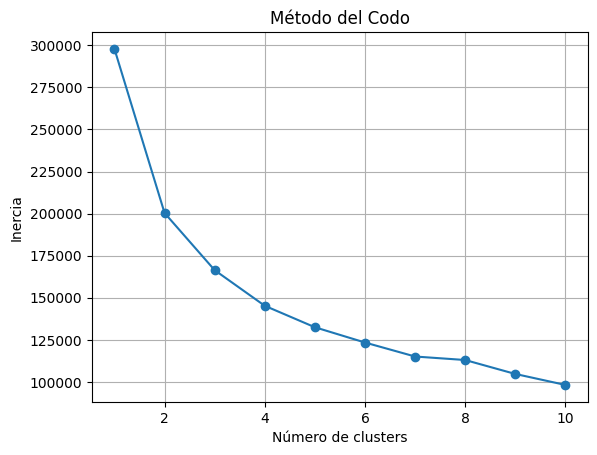

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.plot(rango_k, inercia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

In [ ]:
k_optimo = 2
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
clusters = kmeans.fit_predict(X)

# Añadimos los clusters al dataframe
df['cluster'] = clusters

In [ ]:
# Comparación de conglomerados y características que los definen
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'cluster' in columnas_numericas:
    columnas_numericas.remove('cluster')

df.groupby('cluster')[columnas_numericas].mean()

,year,desplazamiento,cilindros,co2,clase_tipo,consumo_litros_milla
cluster,,,,,,
0,2000.535691,4.167625,6.784572,535.902658,3.369306,0.227449
1,2001.240993,2.246856,4.356504,384.133541,3.482098,0.163336


### **EJERCICIO C:**

Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos.
También, calcule las principales medidas de evaluación externa tomando una cantidad de clusters de 8 y de referencia a la variable clase_tipo.

In [ ]:
# Medidas de evaluación interna
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette Score:", silhouette_score(X, df['cluster']))
print("Davies-Bouldin Score:", davies_bouldin_score(X, df['cluster']))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, df['cluster']))

Silhouette Score: 0.27484527668169656
Davies-Bouldin Score: 1.4125226342982213
Calinski-Harabasz Score: 16945.72331658166


#### Interpretación:

Los resultados de las métricas internas indican que la calidad del agrupamiento es moderada. El Silhouette Score de aproximadamente 0.275 sugiere que los clústeres tienen una separación aceptable, pero no muy clara; es decir, algunos puntos podrían estar cerca de los bordes entre clústeres. El Davies-Bouldin Score de 1.41 muestra que existe cierta superposición entre los grupos (valores más cercanos a 0 serían ideales). Por otro lado, el Calinski-Harabasz Score de 16,945.72 indica que, aunque hay cierta dispersión y diferenciación entre los clústeres, no es lo suficientemente pronunciada para considerarse excelente. En conjunto, se puede concluir que los clústeres son válidos pero podrían mejorarse con una mejor selección de variables o mayor segmentación.

In [ ]:
# Medidas de evaluación externa

# Solo si tienes la columna clase_tipo en tu dataset original
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

if 'clase_tipo' in df.columns:
    df['clase_tipo'] = LabelEncoder().fit_transform(df['clase_tipo'])

    kmeans_8 = KMeans(n_clusters=8, random_state=42)
    clusters_8 = kmeans_8.fit_predict(X)

    print("ARI (Adjusted Rand Index):", adjusted_rand_score(df['clase_tipo'], clusters_8))
    print("NMI (Normalized Mutual Info):", normalized_mutual_info_score(df['clase_tipo'], clusters_8))
else:
    print("No se encontró la variable 'clase_tipo' en el dataset.")

ARI (Adjusted Rand Index): 0.05097270586674314
NMI (Normalized Mutual Info): 0.13566584037478993


#### Interpretación:
Los resultados de las métricas externas muestran que el agrupamiento obtenido con K-means (k=8) tiene baja concordancia con la clasificación real representada por la variable ‘clase_tipo’. El Adjusted Rand Index (ARI) de 0.051 indica que hay muy poca similitud entre los clústeres generados y las clases reales, y que cualquier coincidencia puede deberse al azar. Del mismo modo, el Normalized Mutual Information (NMI) de 0.136 sugiere que la información compartida entre ambos agrupamientos es muy limitada. En resumen, los clústeres formados no reflejan de manera precisa la estructura de clases definida por la variable ‘clase_tipo’.